In [1]:
import os
os.environ["WORLD_SIZE"] = "1"
os.environ["RANK"] = "0"
os.environ["LOCAL_RANK"] = "0"
os.environ["MASTER_ADDR"] = "localhost"
os.environ["MASTER_PORT"] = "12355"

# Benchmarking in the Absence of Ground Truth Data

Comparing the model prediction with the simulation/experimental data is an excellent way to build confidence in the model predictions. However, in a test scenario where the model is used in the absence of any ground truth data (true inference setting), it is difficult to estimate whether the model predictions are reasonable and trustworthy. 

In this notebook, we provide a few approaches one can take to understand the model behavior in different inference settings and build error estimates. More specifically, we will demonstrate case studies to analyze the sensitivity of the model toward mesh resolution, model checkpoints, and explore ways to quantify out-of-sample scenarios. 

## Analyze the Model's Sensitivity to Input (STL) Resolution

The DoMINO model used in this study takes in the STL file and predicts the solution on desired points. We can study how sensitive the model is to the STL's resolution by creating realizations of the same STL at various mesh densities and distributions.

Let's start by creating a few variations of the 202 sample ID by decimating the mesh, subdividing the mesh, etc. We will use `trimesh` to perform these operations. 

In [2]:
import pyvista as pv
import trimesh
import glob
import os

mesh = trimesh.load_mesh("drivaer_202.stl")

# Clean-up already existing files
files_to_delete = glob.glob("remeshed_variant_*.stl")
for file_path in files_to_delete:
    os.remove(file_path)
    
# Create a few remeshed variants
for variant in range(8):
    remeshed_mesh = mesh.copy()
    
    if variant == 0:
        target_faces = int(len(remeshed_mesh.faces) * 0.5)
        remeshed_mesh = remeshed_mesh.simplify_quadric_decimation(face_count=target_faces)
        
    elif variant == 1:
        target_faces = int(len(remeshed_mesh.faces) * 0.25)
        remeshed_mesh = remeshed_mesh.simplify_quadric_decimation(face_count=target_faces)
        
    elif variant == 2:
        remeshed_mesh = remeshed_mesh.subdivide()
              
    elif variant == 3:
        remeshed_mesh.update_faces(remeshed_mesh.nondegenerate_faces())
        remeshed_mesh.update_faces(remeshed_mesh.unique_faces())
        remeshed_mesh.remove_infinite_values()
        remeshed_mesh.remove_unreferenced_vertices()
        
    elif variant == 4:
        remeshed_mesh.fix_normals()
        
    elif variant == 5:
        target_faces = int(len(remeshed_mesh.faces) * 0.7)
        remeshed_mesh = remeshed_mesh.simplify_quadric_decimation(face_count=target_faces)
        remeshed_mesh = remeshed_mesh.subdivide()
        
    elif variant == 6:
        remeshed_mesh = remeshed_mesh.subdivide()
        target_faces = int(len(remeshed_mesh.faces) * 0.6)
        remeshed_mesh = remeshed_mesh.simplify_quadric_decimation(face_count=target_faces)
        
    elif variant == 7:
        remeshed_mesh.update_faces(remeshed_mesh.nondegenerate_faces())
        remeshed_mesh.update_faces(remeshed_mesh.unique_faces())
        remeshed_mesh.remove_infinite_values()
        target_faces = int(len(remeshed_mesh.faces) * 0.8)
        remeshed_mesh = remeshed_mesh.simplify_quadric_decimation(face_count=target_faces)
    
    # Ensure watertight mesh for all variants
    remeshed_mesh.fill_holes()
    remeshed_mesh.update_faces(remeshed_mesh.nondegenerate_faces())
    remeshed_mesh.update_faces(remeshed_mesh.unique_faces())
    remeshed_mesh.remove_infinite_values()
    remeshed_mesh.remove_unreferenced_vertices()
    remeshed_mesh.fix_normals()
    
    # Save the remeshed mesh
    remeshed_mesh.export(f"remeshed_variant_{variant}.stl")

Now that we have these different variations generated, we can run the DoMINO model on each of them and visualize the standard deviation of the fields on a fixed set of points. These can be any set of points; for this study, we pick them from the "meshed" version of the original STL, i.e., the `.vtp` file. 

In [3]:
import pyvista as pv
_xvfb = getattr(pv, "start_xvfb", None)
if _xvfb is not None:
    _xvfb()
else:
    pv.OFF_SCREEN = True

mesh = pv.read("./boundary_202.vtp")
mesh

/tmp/ipykernel_473319/2477101432.py:2: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk with osmesa instead.
  pv.start_xvfb()


PolyData (0x7fff9c062920)
  N Cells:    8883343
  N Points:   8902069
  N Strips:   0
  X Bounds:   -9.240e-01, 3.886e+00
  Y Bounds:   -1.061e+00, 1.061e+00
  Z Bounds:   -3.176e-01, 1.074e+00
  N Arrays:   5

In [4]:
import glob
import numpy as np
import os
import time
from pathlib import Path
from physicsnemo.cfd.evaluation.models.wrappers.domino.wrapper import DominoWrapper
from physicsnemo.cfd.evaluation.datasets.schema import CanonicalCase

CHECKPOINT_DIR = "/lustre/fsw/coreai_modulus_cae/ktangsali/aero-benchmarking/physicsnemo-external-aero-checkpoints/domino_drivaerml_checkpoint"

wrapper = DominoWrapper()
wrapper.load(
    checkpoint_path=f"{CHECKPOINT_DIR}/surface/DoMINO.0.535.mdlus",
    stats_path="",
    device="cuda:0",
    domino_config=f"{CHECKPOINT_DIR}/config_surface.yaml",
)

stl_files = glob.glob("remeshed_variant_*.stl")

pMeanTrimPred = []
wallShearStressMeanTrimPred = []
stl_link = Path("drivaer_202.stl")
for i, stl_file in enumerate(stl_files):
    print(f"Processing {i}: {stl_file}")
    start_time = time.time()

    # The wrapper finds the STL by convention (drivaer_{tag}.stl).
    # Symlink each variant so the wrapper picks it up.
    if stl_link.exists() or stl_link.is_symlink():
        stl_link.unlink()
    stl_link.symlink_to(Path(stl_file).resolve())

    case = CanonicalCase(
        case_id="run_202",
        mesh_path="./boundary_202.vtp",
        mesh_type="cell",
        inference_domain="surface",
    )
    model_input = wrapper.prepare_inputs(case)
    raw_output = wrapper.predict(model_input)
    predictions = wrapper.decode_outputs(raw_output, case)

    pMeanTrimPred.append(predictions["pressure"])
    wallShearStressMeanTrimPred.append(predictions["shear_stress"])
    print(f"  Inference took {time.time() - start_time:.3f} sec")

mesh

Warp DeprecationWarning: The namespace `warp.context` will soon be removed from the public API. It can still be accessed from `warp._src.context` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/usr/local/lib/python3.12/dist-packages/torch/library.py:357: UserWarning: Warning only once for all operators,  other operators may also be overridden.
  Overriding a previously registered kernel for the same operator and the same dispatch key
  operator: flash_attn::_flash_attn_backward(Tensor dout, Tensor q, Tensor k, Tensor v, Tensor out, Tensor softmax_lse, Tensor(a6!)? dq, Tensor(a7!)? dk, Tensor(a8!)? dv, float dropout_p, float softmax_scale, bool causal, SymInt window_size_left, SymInt window_size_right, float softcap, Tensor? alibi_slopes, bool deterministic, Tensor? rng_state=None) -> Tensor
    registered at /usr/local/lib/python3.12/dist-packages/torch/_library/custom_ops.py:926
  dispatch key: ADInplaceOrView
  previous kernel: no debug info
       new kernel: registered at /usr/local/lib/python3.12/dist-packages/torch/_library/custom_ops.py:926 (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/core/dispatch/OperatorEntry.cpp:208.)
  self.m.impl(
/workspace/aero-

[inference:domino] Loading DoMINO config from /lustre/fsw/coreai_modulus_cae/ktangsali/aero-benchmarking/physicsnemo-external-aero-checkpoints/domino_drivaerml_checkpoint/config_surface.yaml; checkpoint from /lustre/fsw/coreai_modulus_cae/ktangsali/aero-benchmarking/physicsnemo-external-aero-checkpoints/domino_drivaerml_checkpoint/surface/DoMINO.0.535.mdlus


[inference:domino] Loading checkpoint from directory /lustre/fsw/coreai_modulus_cae/ktangsali/aero-benchmarking/physicsnemo-external-aero-checkpoints/domino_drivaerml_checkpoint/surface


...

/usr/local/lib/python3.12/dist-packages/cuml/__init__.py:95: FutureWarning: cuml.Handle was deprecated in 26.02 and will be removed in 26.04. There is no need to manually specify a `handle`, cuml now manages this resource for you automatically.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/cuml/internals/base.py:43: FutureWarning: The `handle` argument to `NearestNeighbors` was deprecated in 26.02 and will be removed in 26.04. There is no need to manually specify a `handle`, cuml now manages this resource for you automatically.
  warnings.warn(


[inference:domino] Running forward pass (predicting surface fields)…


[inference:domino] Decoding outputs (pressure + WSS to numpy)…


  Inference took 25.647 sec


PolyData (0x7fff9c062920)
  N Cells:    8883343
  N Points:   8902069
  N Strips:   0
  X Bounds:   -9.240e-01, 3.886e+00
  Y Bounds:   -1.061e+00, 1.061e+00
  Z Bounds:   -3.176e-01, 1.074e+00
  N Arrays:   5

In [5]:
pMeanTrimPred_mean = np.mean(np.stack(pMeanTrimPred, axis=0), axis=0)
pMeanTrimPred_std = np.std(np.stack(pMeanTrimPred, axis=0), axis=0)
wallShearStressMeanTrimPred_mean = np.mean(np.stack(wallShearStressMeanTrimPred, axis=0), axis=0)
wallShearStressMeanTrimPred_std = np.std(np.stack(wallShearStressMeanTrimPred, axis=0), axis=0)

mesh.cell_data[f"pMeanTrimPred_mean"] = pMeanTrimPred_mean
mesh.cell_data[f"pMeanTrimPred_std"] = pMeanTrimPred_std
mesh.cell_data[f"wallShearStressMeanTrimPred_mean"] = wallShearStressMeanTrimPred_mean
mesh.cell_data[f"wallShearStressMeanTrimPred_std"] = wallShearStressMeanTrimPred_std

/workspace/aero-benchmarking/physicsnemo-cfd/physicsnemo/cfd/postprocessing_tools/visualization/utils.py:26: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk with osmesa instead.
  pv.start_xvfb()


2026-04-10 13:11:29.706 ( 782.904s) [    7FFFF7C73540]    vtkX11Functions.cxx:194   WARN| Failed to load Xcursor library
2026-04-10 13:11:29.781 ( 782.979s) [    7FFFF7C73540]    vtkX11Functions.cxx:194   WARN| Failed to load Xcursor library


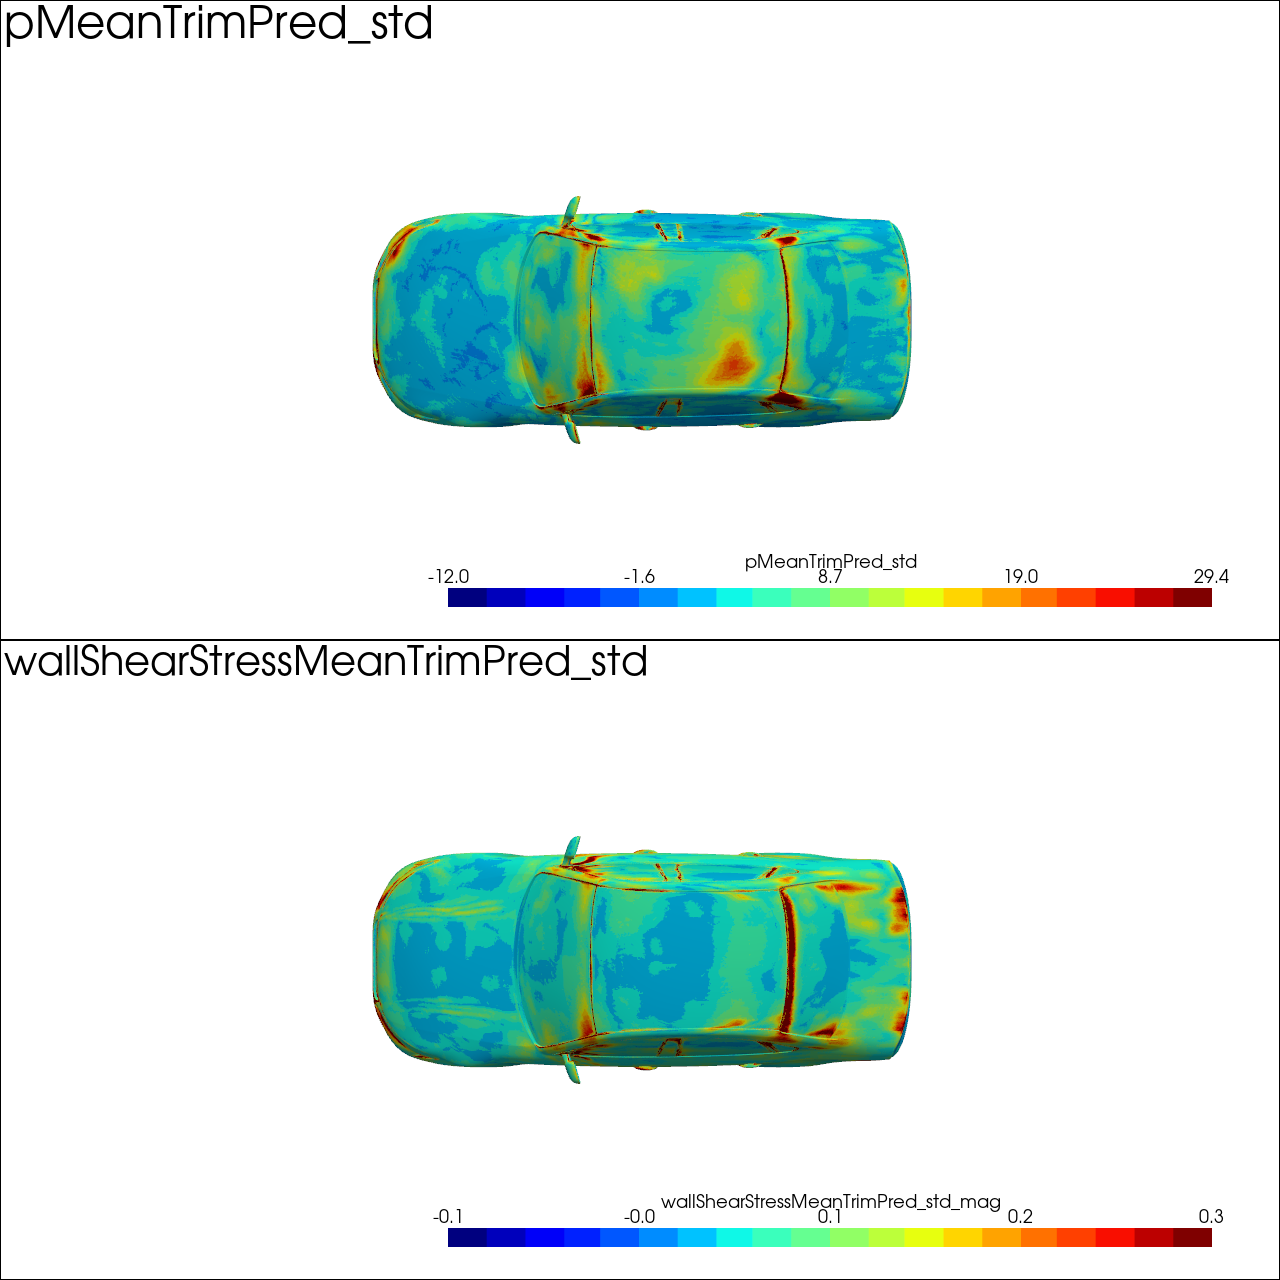

In [6]:
from physicsnemo.cfd.postprocessing_tools.visualization.utils import plot_fields

fields_to_plot = ["pMeanTrimPred_std", "wallShearStressMeanTrimPred_std"]
plotter = plot_fields(mesh, 
    fields_to_plot,
    plot_vector_components=False,
    view="xy",
    dtype="cell",
    cmap="jet",
    lut=20,
    window_size=[1280, 1280],
)
plotter.screenshot("./variations_with_mesh_xy.png")

# Display the image
from IPython.display import Image

Image(filename="./variations_with_mesh_xy.png")

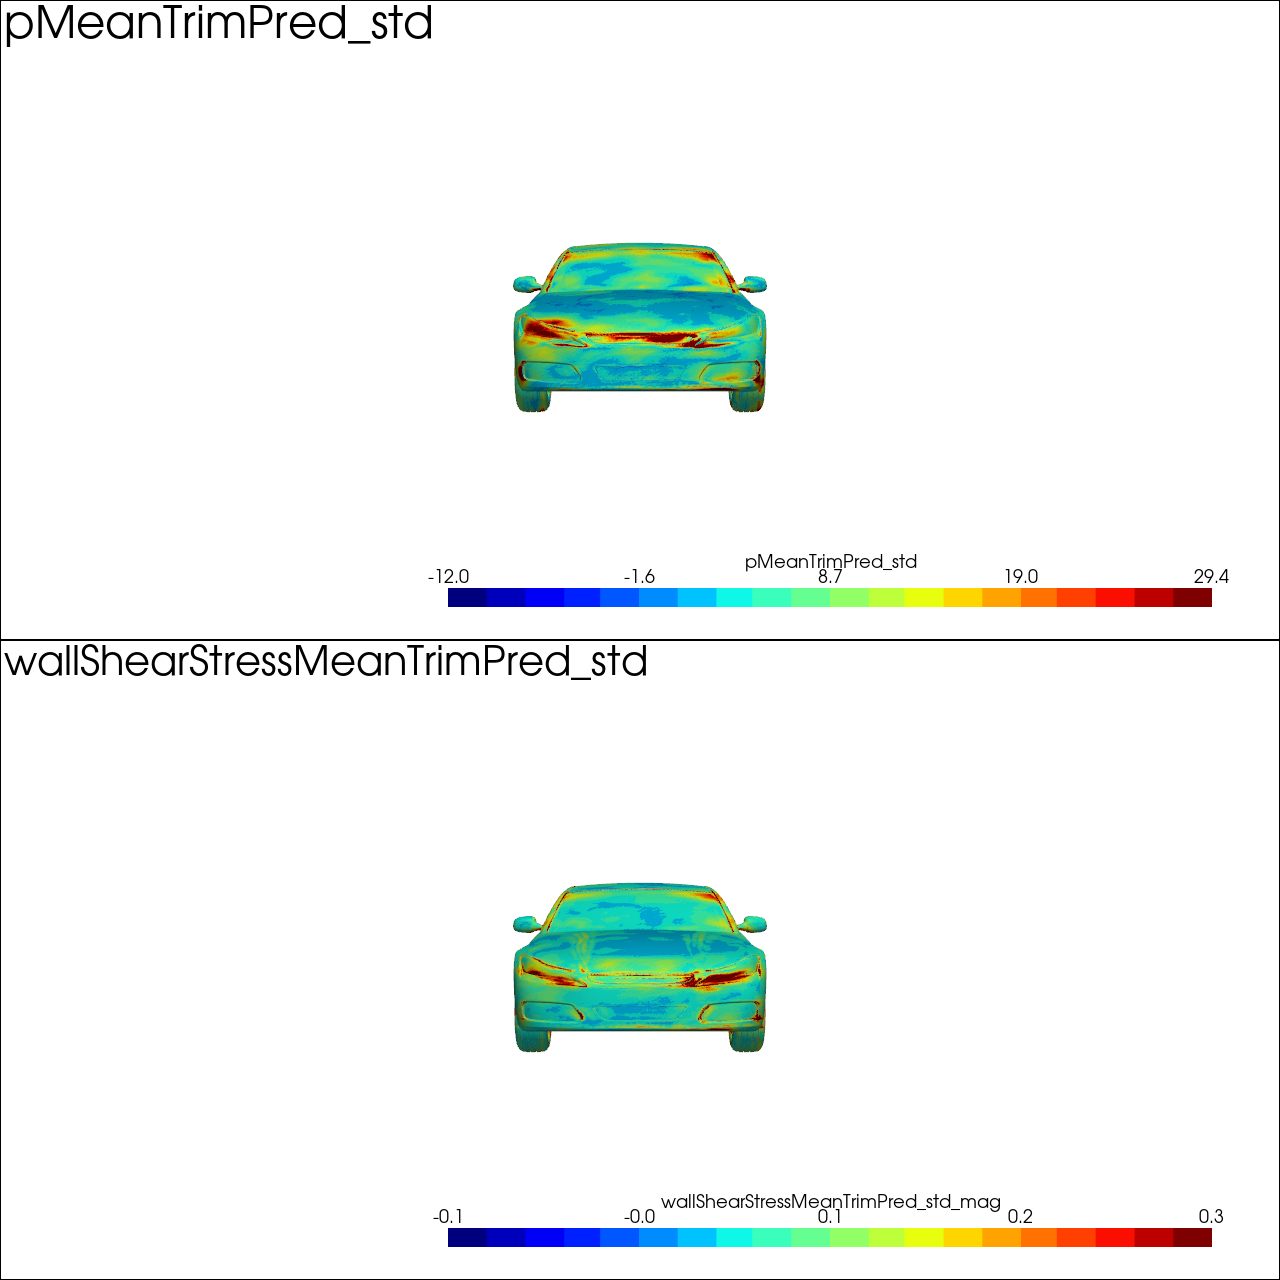

In [7]:
from physicsnemo.cfd.postprocessing_tools.visualization.utils import plot_fields

fields_to_plot = ["pMeanTrimPred_std", "wallShearStressMeanTrimPred_std"]
plotter = plot_fields(mesh, 
    fields_to_plot,
    plot_vector_components=False,
    view="yz",
    view_negative=True,
    dtype="cell",
    cmap="jet",
    lut=20,
    window_size=[1280, 1280],
)
plotter.screenshot("./variations_with_mesh_yz.png")

# Display the image
from IPython.display import Image

Image(filename="./variations_with_mesh_yz.png")

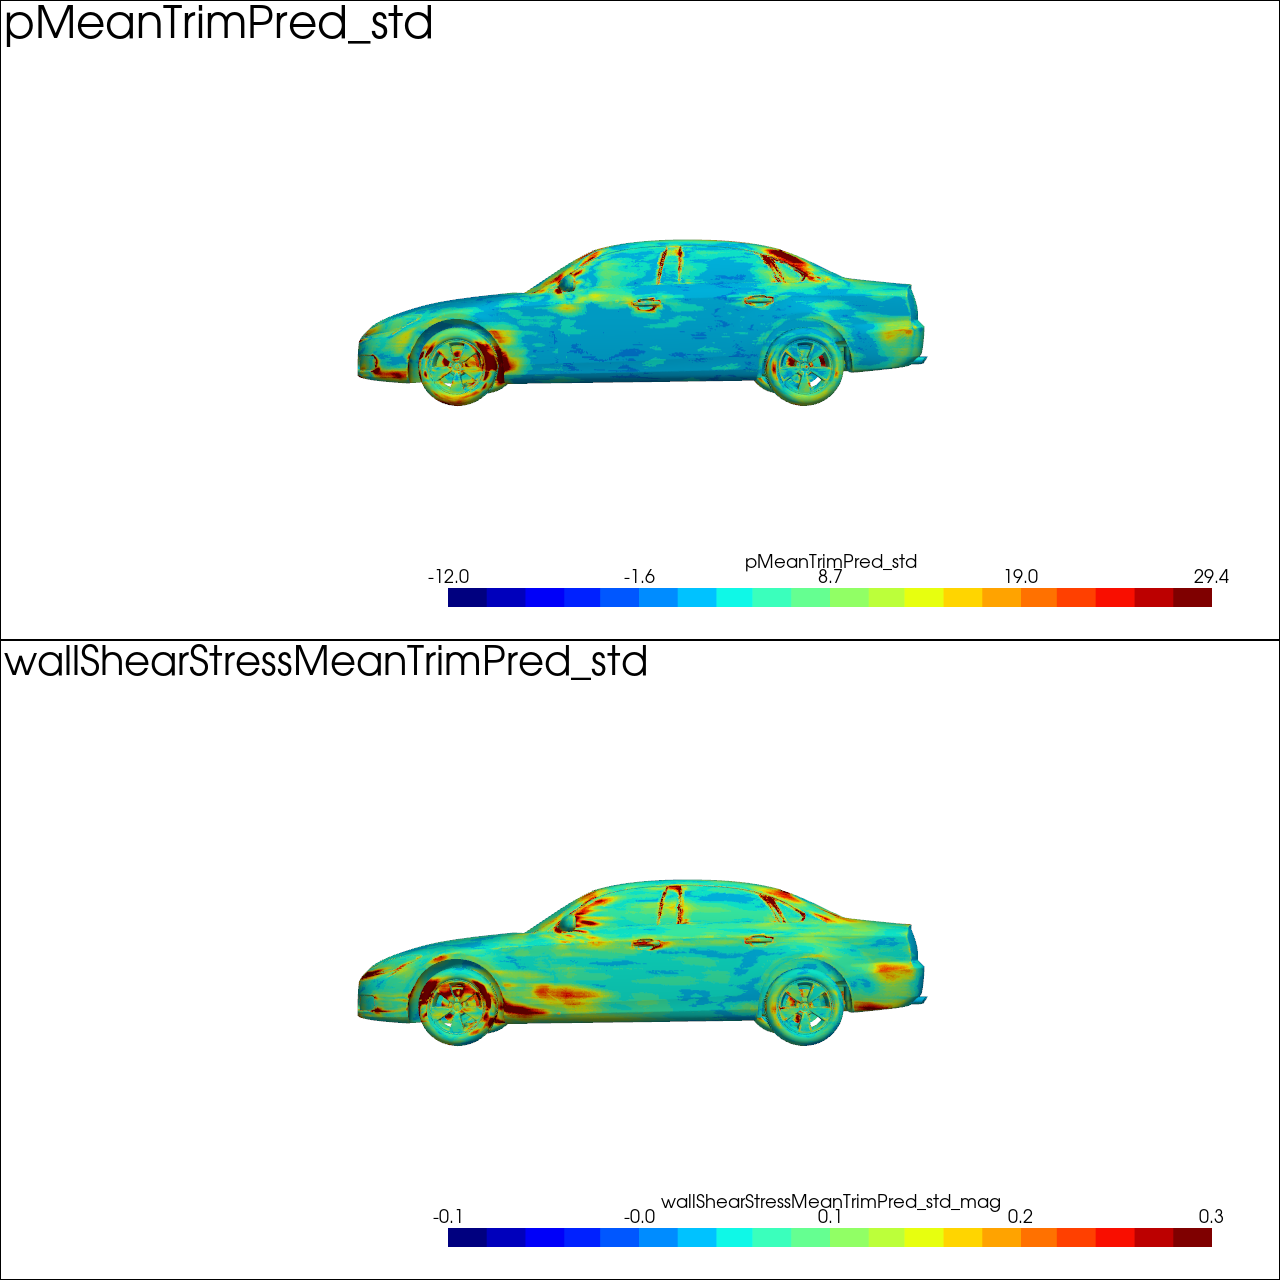

In [8]:
from physicsnemo.cfd.postprocessing_tools.visualization.utils import plot_fields

fields_to_plot = ["pMeanTrimPred_std", "wallShearStressMeanTrimPred_std"]
plotter = plot_fields(mesh, 
    fields_to_plot,
    plot_vector_components=False,
    view="xz",
    view_negative=False,
    dtype="cell",
    cmap="jet",
    lut=20,
    window_size=[1280, 1280],
)
plotter.screenshot("./variations_with_mesh_xz.png")

# Display the image
from IPython.display import Image

Image(filename="./variations_with_mesh_xz.png")

We can observe that just by changing the input STL resolution/remeshing, the predictions of the model change. The fields show a high variance near the edges, which is expected, as that is where the mesh changes affect the topology. However, in addition to the edges, the model results also show high variance in areas where the topology does not change much, for example, some areas of the roof, wheels, and the sides of the car. 

## Analyze the Model's Sensitivity to Checkpoint

AI models are trained using stochastic gradient descent, and that leads to randomness in the model outputs. The model outputs can change based on when the model is checkpointed. Additionally, for a different input seed, the model can produce a different checkpoint. Typically this variation is limited as the learning rate at the end of the training is typically very small; however, there are still some oscillations present. One can save out the last few checkpoints after the model training has reached "statistical" convergence, and then use them to produce an ensemble of results and study the variance as above. 

Since we don't ship various checkpoints with DoMINO, presently we directly present the results of such an analysis; however, the process to compute them would be similar as before, i.e., for the same input points, get the predictions of various model checkpoints and use them to build statistics. 

The figure below shows the results of such an analysis. The analysis shows the standard deviation for pressure and wall shear stress for two samples from the validation set (439 on the left and 419 on the right).

![Variation due to model Checkpoint](img/variations_due_to_checkpoint.png)

We observe that more variation is observed on the front, wheels, and mirrors for the pressure, while for wall shear stress, the mirrors and wheels show a higher degree of sensitivity toward the model checkpoints.  

## Quantifying Geometric Similarity

The DoMINO model is trained on a diverse set of vehicle geometries that include different types of passenger automobiles such as vans, pickup trucks, SUVs, sedans, etc. This means that the model is expected to perform well when the inference is computed on an unseen geometry from this class. On the contrary, a vehicle that is significantly out of distribution cannot be used for the inference. Quantifying whether a geometry is in-distribution or out-of-distribution can be hard for 3D shapes. To tackle this, we provide metrics to compute the relative distance between two geometries (Chamfer distance and Hausdorff distance). 

Below, we demonstrate how this can be used to build an understanding of the space of the training geometry data and get an estimate of how much the sample is "out-of-distribution". 

First, to demonstrate, we will take two samples from the DrivAerML dataset that are fairly close to one another, and then the AeroSUV sample. Our goal would be to quantitatively distinguish between these two samples. 

The code below will download the AeroSUV sample.

In [9]:
import os
import requests
import zipfile
import trimesh

zip_url = "https://www.ecara.org/fileadmin/media/dateien/AeroSUV/3_STL_Datensatz.zip"
zip_filename = "3_STL_Datensatz.zip"
extract_folder = "extracted_stl"
output_file = "merged_aerosuv.stl"

selected_stl_files = [
    "3_STL_Datensatz/01_body.stl",
    "3_STL_Datensatz/02_side-mirrors.stl",
    "3_STL_Datensatz/03_rear-end_estate.stl",
    "3_STL_Datensatz/08_underbody-flat.stl",
    "3_STL_Datensatz/02_side-mirrors.stl",
    "3_STL_Datensatz/17_wheels-front.stl",
    "3_STL_Datensatz/18_wheels-rear.stl",
    "3_STL_Datensatz/20_cooling-air-closing.stl",
]

print("Downloading ZIP...")
response = requests.get(zip_url)
with open(zip_filename, "wb") as f:
    f.write(response.content)
print("Download complete.")

os.makedirs(extract_folder, exist_ok=True)
print("Extracting selected STL files...")
with zipfile.ZipFile(zip_filename, "r") as zip_ref:
    for stl in selected_stl_files:
        try:
            zip_ref.extract(stl, extract_folder)
            print(f"Extracted: {stl}")
        except KeyError:
            print(f"File not found in ZIP: {stl}")
print("Extraction complete.")

mesh_list = []
for stl in selected_stl_files:
    stl_path = os.path.join(extract_folder, stl)
    if os.path.exists(stl_path):
        mesh = trimesh.load(stl_path, force='mesh')
        mesh_list.append(mesh)

if not mesh_list:
    raise ValueError("No valid STL files were loaded.")

print(f"Merging {len(mesh_list)} meshes...")
combined = trimesh.util.concatenate(mesh_list)

# Scale to bring it closer to DrivAerML STls. 
combined.apply_scale(1/254) 
combined.apply_translation([0, 0, -0.296])

combined.export(output_file)
print(f"Merged and scaled STL saved as '{output_file}'")


Download complete.
Extracting selected STL files...


Extracted: 3_STL_Datensatz/01_body.stl
Extracted: 3_STL_Datensatz/02_side-mirrors.stl
Extracted: 3_STL_Datensatz/03_rear-end_estate.stl


Extracted: 3_STL_Datensatz/08_underbody-flat.stl
Extracted: 3_STL_Datensatz/02_side-mirrors.stl


Extracted: 3_STL_Datensatz/17_wheels-front.stl


Extracted: 3_STL_Datensatz/18_wheels-rear.stl
Extracted: 3_STL_Datensatz/20_cooling-air-closing.stl
Extraction complete.


Merging 8 meshes...


Merged and scaled STL saved as 'merged_aerosuv.stl'


Next, we will download sample IDs 418 and 420 as these are very similar to one another visually. 

In [10]:
filenames = [
    "drivaer_418.stl",
    "drivaer_420.stl",
]
urls = [
    "https://huggingface.co/datasets/neashton/drivaerml/resolve/main/run_418/drivaer_418.stl",
    "https://huggingface.co/datasets/neashton/drivaerml/resolve/main/run_420/drivaer_420.stl",
]

for filename, url in zip(filenames, urls):
    if not os.path.exists(filename):
        !wget "{url}" -O "{filename}"
    else:
        print(f"{filename} already exists. Skipping download.")

drivaer_418.stl already exists. Skipping download.
drivaer_420.stl already exists. Skipping download.


Let's visualize them together.

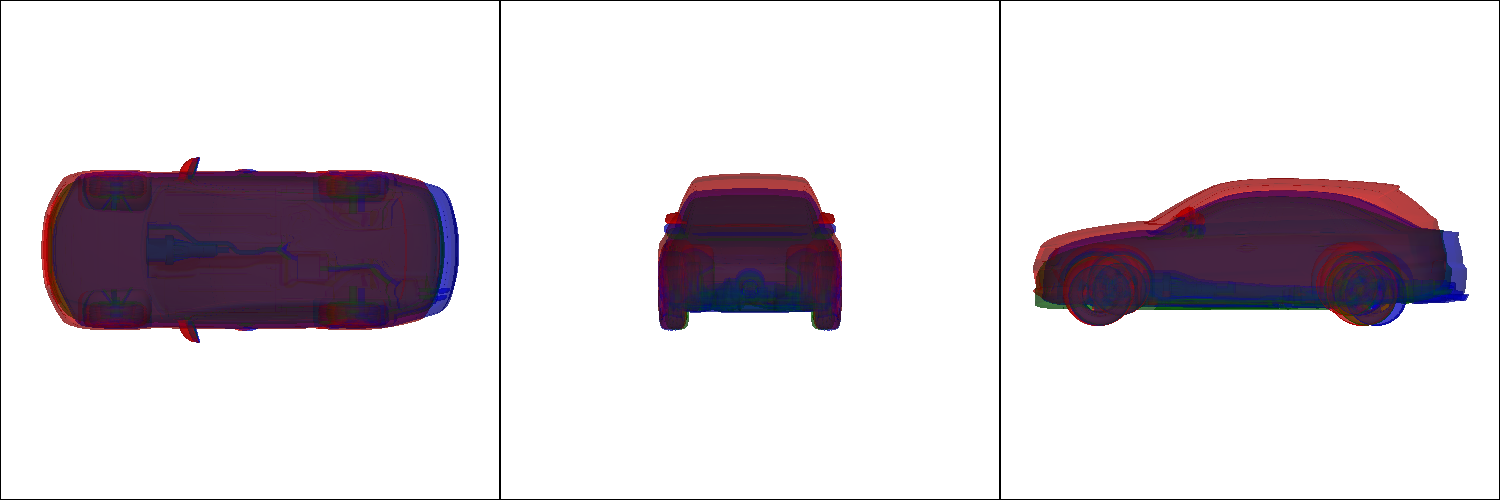

In [11]:
aero_suv = pv.read("merged_aerosuv.stl")
sedan_1 = pv.read("drivaer_418.stl")
sedan_2 = pv.read("drivaer_420.stl")

plotter = pv.Plotter(shape=(1, 3), off_screen=True, window_size=(1500, 500))

def add_all_meshes(p, view_func):
    p.add_mesh(aero_suv, opacity=0.5, show_edges=False, color='red')
    p.add_mesh(sedan_1, opacity=0.5, show_edges=False, color='green')
    p.add_mesh(sedan_2, opacity=0.5, show_edges=False, color='blue')
    view_func()
    p.reset_camera()
    p.set_background("white")

plotter.subplot(0, 0)
add_all_meshes(plotter, plotter.view_xy)

plotter.subplot(0, 1)
add_all_meshes(plotter, plotter.view_yz)

plotter.subplot(0, 2)
add_all_meshes(plotter, plotter.view_xz)

plotter.set_background("white")
plotter.screenshot("./stl_comparisons.png")

# Display the image
from IPython.display import Image

Image(filename="./stl_comparisons.png")

Now let's compute the relative distances.

In [12]:
from physicsnemo.cfd.postprocessing_tools.geometry.distance import chamfer_distance, hausdorff_distance

sedan_1_vs_aerosuv = chamfer_distance(sedan_1.points, aero_suv.points)
sedan_2_vs_aerosuv = chamfer_distance(sedan_2.points, aero_suv.points)
sedan_1_vs_sedan_2 = chamfer_distance(sedan_1.points, sedan_2.points)
print(sedan_1_vs_aerosuv, sedan_2_vs_aerosuv, sedan_1_vs_sedan_2)

0.0576326009777469 0.05471310619482909 0.03239957394205294


In [13]:
sedan_1_vs_aerosuv = hausdorff_distance(sedan_1.points, aero_suv.points)
sedan_2_vs_aerosuv = hausdorff_distance(sedan_2.points, aero_suv.points)
sedan_1_vs_sedan_2 = hausdorff_distance(sedan_1.points, sedan_2.points)
print(sedan_1_vs_aerosuv, sedan_2_vs_aerosuv, sedan_1_vs_sedan_2)

0.37145597389151735 0.35232097572016974 0.19132546164645767


We observe that the distance (Chamfer and Hausdorff) between the two sedans is lower than the same between the SUV and either of the sedans. 

The distance measures can be used to make these relative distance queries and quantify the in-distribution vs. out-of-distribution nature of the sample. 

For example, below, we take a few samples from each class (SUV, sedan, pickup, hatchback, van) from the dataset that was used for DoMINO training and compare it with the sedans from DrivAerML. We see that the validation samples from the DrivAerML are the closest to the training samples from DrivAerML. This is followed by the sedans from the DriveSim, sports cars, hatchback, van, and SUV from DriveSim. The most different are the pickup trucks from DriveSim, which makes sense as that represents a significant geometric variation when compared to a sedan. 

![Chamfer Distances](img/chamfer-distances-drivaerml.png)